# Adaptive RAG (Adaptive Retrieval-Augmented Generation)

## Table of Contents
1. [What is Adaptive RAG?](#what-is-adaptive-rag)
2. [Why, When, and How to Use It](#why-when-and-how-to-use-it)
3. [Flowchart & State Machine](#flowchart--state-machine)
4. [Pros and Cons](#pros-and-cons)
5. [Real-World Case Study: Adaptive Tech Support System](#real-world-case-study-adaptive-tech-support-system)
6. [Building from Scratch in LangGraph](#building-from-scratch-in-langgraph)

---

## What is Adaptive RAG?

**Adaptive RAG** (introduced in papers like *Adaptive-RAG: Learning to Adapt Retrieval-Augmented Generation*) is an advanced RAG architecture that dynamically adapts its retrieval strategy based on the complexity and type of the incoming user query. 

Rather than treating all questions equally, Adaptive RAG uses a **Query Classifier/Router** (usually a fast, fine-tuned model or a structured LLM call) to analyze the query first. It then routes the request to the most efficient pipeline:
1. **No Retrieval (Direct Generation)**: For greetings, general knowledge, or simple conversational queries.
2. **Single-Hop / Standard RAG**: For queries requiring a quick lookup of specific documents in a local vector database.
3. **Multi-Hop / Web-Augmented RAG**: For complex, multi-part, or time-sensitive questions requiring multiple retrieval steps, query rewriting, or external web searching.

Additionally, it incorporates self-grading mechanisms (document relevance, hallucination, and answer verification) to guarantee response accuracy.

---

## Why, When, and How to Use It

### Why Use Adaptive RAG?
Standard RAG systems suffer from two main issues:
- **Inefficiency**: They retrieve documents even for simple queries like "Hello, how are you?" or basic programming syntax questions that the LLM already knows, wasting tokens and increasing latency.
- **Inadequacy**: They struggle with complex or time-sensitive queries that cannot be answered in a single vector retrieval step, leading to incomplete or outdated responses.

Adaptive RAG balances **latency, cost, and accuracy** by matching the query's complexity with the right execution path.

### When to Use It
- **Heterogeneous User Traffic**: In production systems (like customer support chatbots) receiving a mixture of chit-chat, simple FAQs, and highly complex technical troubleshooting questions.
- **Dynamic Data Requirements**: When some questions require internal corporate wikis, while others require real-time public web searches.
- **Latency and Budget Optimization**: When you want to minimize API calls and vector search compute overhead for trivial interactions.

### How it Works (The Core Steps)
1. **Query Analysis**: Analyze the query's intent, complexity, and temporal nature.
2. **Routing Decision**: Route to one of three paths: `direct_response`, `local_rag`, or `web_search`/`multi_hop`.
3. **Retrieval & Grading**: If retrieval is used, grade the retrieved documents for relevance.
4. **Iterative Refinement**: If documents are irrelevant, rewrite the query and fetch again (either locally or globally).
5. **Hallucination & Answer Grading**: Before returning the response, verify that the answer is grounded in the retrieved documents (no hallucinations) and fully answers the user's question.

---

## Flowchart & State Machine

### High-Level Routing & Refinement Workflow

```mermaid
graph TD
    UserQuery[User Query] --> Classifier{Query Classifier}
    
    Classifier -->|Chit-Chat / General Knowlege| DirectGen[Direct Generation]
    Classifier -->|Specific Internal Knowledge| LocalRAG[Local Vector Retrieval]
    Classifier -->|Complex / Real-Time Info| WebSearch[Web / Multi-Hop Search]
    
    LocalRAG --> DocGrader{Are Docs Relevant?}
    DocGrader -->|Yes| LocalGenerate[Generate Answer]
    DocGrader -->|No| QueryRewrite[Rewrite Query]
    
    QueryRewrite --> WebSearch
    
    WebSearch --> WebGenerate[Generate Answer]
    
    LocalGenerate --> HallucinationCheck{Hallucination Grader}
    WebGenerate --> HallucinationCheck
    
    HallucinationCheck -->|Hallucinated| RefineGeneration[Refine & Regenerate]
    RefineGeneration --> HallucinationCheck
    
    HallucinationCheck -->|Grounded| AnswerGrader{Does Answer Address Query?}
    
    AnswerGrader -->|Yes| Output[Final Balanced Answer]
    AnswerGrader -->|No| Fallback[Escalate to Human / Detailed Search]
```

### Detailed LangGraph State Machine

```mermaid
stateDiagram-v2
    [*] --> AnalyzeQuery: Start
    
    AnalyzeQuery --> DirectResponse: Route = direct
    AnalyzeQuery --> RetrieveLocal: Route = local_rag
    AnalyzeQuery --> RetrieveWeb: Route = web_search
    
    DirectResponse --> [*]
    
    RetrieveLocal --> GradeDocuments
    
    GradeDocuments --> GenerateAnswer: Has Relevant Docs
    GradeDocuments --> RewriteQuery: All Docs Irrelevant
    
    RewriteQuery --> RetrieveWeb
    RetrieveWeb --> GenerateAnswer
    
    GenerateAnswer --> GradeGeneration
    
    GradeGeneration --> [*]: Grounded & Answers Query
    GradeGeneration --> GenerateAnswer: Hallucinated (Regenerate)
    GradeGeneration --> RetrieveWeb: Grounded but Incomplete (Escalate Search)
```

---

## Pros and Cons

### Pros
- **Optimized Latency**: Bypasses vector searches and document loading for simple or conversational inputs.
- **Cost Reduction**: Significantly lowers token counts by not feeding massive context windows to the LLM when unnecessary.
- **High Accuracy & Guardrails**: Evaluates both document relevance and answer faithfulness, virtually eliminating hallucinations.
- **Adaptability**: Flexes dynamically between local proprietary files and public web searching.

### Cons
- **Higher Routing Latency**: The initial routing step adds a small LLM overhead to every query (mitigated by using fast, lightweight models like Llama 3.1 8B).
- **Complexity**: Multiple state transitions, conditional edges, and structured outputs make the graph complex to design and debug.
- **Prompt Sensitivity**: Highly dependent on the quality of the grading and routing prompts.

---

## Real-World Case Study: Adaptive Tech Support System

### Scenario
An enterprise cloud hosting company, **CloudFlow Solutions**, wants to deploy an automated AI support engineer. The engineer receives three kinds of user messages:
1. **Greetings and general conversational messages** (e.g., "Hi, how do I contact billing?" or "Hello!").
2. **Standard documentation queries** (e.g., "What are your storage limits for VM Tier-2?").
3. **Complex, real-time troubleshooting or system status queries** (e.g., "Why is my VM instance in us-east-1 failing to connect right now?" or "Is there an outage in AWS right now?").

### The Approach
- **Direct Route**: Handles chit-chat and directs users to billing contacts without touching the technical knowledge base.
- **Local RAG Route**: Queries the internal Vector Database containing VM tiers, specifications, and SLA documents.
- **Web Search Route**: Triggers a live web search tool to fetch real-time service status, AWS outage reports, and external software patches.

---

## Building from Scratch in LangGraph

The implementation uses LangGraph's state graph structure to orchestrate routing, vector search, document relevance scoring, generation, and answer-faithfulness evaluation. The complete, executable code can be found in the accompanying Python script.

## Complete Implementation Code

In [ ]:
"""
Adaptive RAG (Adaptive Retrieval-Augmented Generation) - LangGraph Implementation
===================================================================================

This script implements an Adaptive RAG pattern:
1. Query Classifier: Classifies user queries into "direct_response", "local_rag", or "web_search".
2. Local RAG Retrieval: Queries a local knowledge base of specifications and internal docs.
3. Web Search Retrieval: Simulates a live external status / troubleshooting search.
4. Document Grader: Filters out irrelevant retrieved context.
5. Hallucination Grader: Checks if the generated answer is faithful to the context.
6. Answer Grader: Assesses whether the response actually answers the query.
"""


In [1]:

import os
from typing import Literal, List, Dict, Any
from pydantic import BaseModel, Field
from dotenv import load_dotenv

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.graph import StateGraph, START, END, MessagesState

# Load environment variables
# load_dotenv(dotenv_path=os.path.join(os.path.dirname(os.path.abspath(__file__)), '..', '.env'))
load_dotenv()


d:\github\Agentic Design Patterns\virtEnvAgenticPatterns\Lib\site-packages\langgraph\checkpoint\base\__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


True

In [2]:

# ==============================================================================
# Dynamic Dual-Provider LLM Setup (OpenAI / Groq)
# ==============================================================================

if os.environ.get("OPENAI_API_KEY"):
    print("[INFO] Detected OpenAI API Key. Running with OpenAI...")
    from langchain_openai import ChatOpenAI
    router_model = ChatOpenAI(model='gpt-4o-mini', temperature=0)
    grader_model = ChatOpenAI(model='gpt-4o-mini', temperature=0)
    generation_model = ChatOpenAI(model='gpt-4o', temperature=0.1)
elif os.environ.get("GROQ_API_KEY"):
    print("[INFO] Detected Groq API Key. Running with Groq...")
    from langchain_groq import ChatGroq
    # Llama 3.3 70B is excellent for structured output and routing
    router_model = ChatGroq(model='llama-3.3-70b-versatile', temperature=0)
    grader_model = ChatGroq(model='llama-3.3-70b-versatile', temperature=0)
    generation_model = ChatGroq(model='llama-3.3-70b-versatile', temperature=0.1)
else:
    raise ValueError("Missing credentials. Set OPENAI_API_KEY or GROQ_API_KEY in your .env file.")


[INFO] Detected Groq API Key. Running with Groq...


In [3]:


# ==============================================================================
# Step 1: Define Mock Knowledge Bases (Local & Web mock)
# ==============================================================================

# Local VM specifications database
LOCAL_DOCS_DB = [
    {
        "title": "VM Tier-1 Specifications",
        "content": "VM Tier-1 (Basic Compute) offers 1 vCPU, 2GB RAM, and 20GB SSD storage. It is designed for lightweight testing and development. Bandwidth limit: 1TB/month. Cost: $5/month."
    },
    {
        "title": "VM Tier-2 Specifications",
        "content": "VM Tier-2 (Standard Compute) offers 2 vCPUs, 8GB RAM, and 80GB SSD storage. It is designed for production web applications and lightweight databases. Bandwidth limit: 5TB/month. Cost: $20/month."
    },
    {
        "title": "VM Tier-3 Specifications",
        "content": "VM Tier-3 (High Performance Compute) offers 8 vCPUs, 32GB RAM, and 300GB NVMe SSD storage. Optimized for data-intensive workloads and high-traffic databases. Bandwidth limit: 10TB/month. Cost: $80/month."
    },
    {
        "title": "CloudFlow Support Contacts",
        "content": "For billing inquiries, email billing@cloudflow.io. For general support, open a ticket at help.cloudflow.io. Customer support hotline: +1-800-555-0199."
    }
]

# Web/Status mock database (for troubleshooting and real-time events)
WEB_SEARCH_DB = [
    {
        "source": "CloudFlow Live Status Page (June 2, 2026)",
        "content": "System Alert: US-East-1 region network congestion detected. Starting at 14:30 UTC, packet loss up to 15% is affecting VM instances. Engineers are rerouting traffic. Estimated resolution: 18:00 UTC."
    },
    {
        "source": "AWS Tech Status Forum (June 2026)",
        "content": "Reported issue: Recent kernel update v6.1.8-generic causes boot failure on Ubuntu 22.04 LTS instances configured with volume-backed root storage. Workaround: Rollback to kernel v6.1.7."
    }
]


In [4]:


# ==============================================================================
# Step 2: Define Retrieval Helper Functions
# ==============================================================================

def retrieve_local_docs(query: str) -> List[str]:
    """Retrieves relevant internal docs from the local DB using simple keyword matching."""
    query_lower = query.lower()
    matches = []
    for doc in LOCAL_DOCS_DB:
        searchable = f"{doc['title']} {doc['content']}".lower()
        if any(word in searchable for word in query_lower.split() if len(word) > 3):
            matches.append(f"[{doc['title']}]: {doc['content']}")
    return matches

def retrieve_web_search(query: str) -> List[str]:
    """Retrieves relevant real-time status/troubleshooting from mock web DB."""
    query_lower = query.lower()
    matches = []
    for doc in WEB_SEARCH_DB:
        searchable = f"{doc['source']} {doc['content']}".lower()
        if any(word in searchable for word in query_lower.split() if len(word) > 3):
            matches.append(f"[{doc['source']}]: {doc['content']}")
    return matches



In [5]:

# ==============================================================================
# Step 3: Define Structured Routing & Grading Schemas
# ==============================================================================

class QueryRoute(BaseModel):
    """Structured output representing the classified query route."""
    route: Literal["direct_response", "local_rag", "web_search"] = Field(
        description="Choose 'direct_response' for greetings/chit-chat. Choose 'local_rag' for specific internal documents, VM specs, and contacts. Choose 'web_search' for real-time outages, tech status, or complex troubleshooting queries."
    )
    reasoning: str = Field(description="Brief explanation of the routing classification.")

class DocumentRelevance(BaseModel):
    """Structured output for grading a document's relevance to the query."""
    relevance: Literal["yes", "no"] = Field(
        description="Score 'yes' if the document contains information relevant to the user query, otherwise score 'no'."
    )
    reasoning: str = Field(description="Explanation of the relevance score.")

class HallucinationScore(BaseModel):
    """Structured output for checking factual alignment of generation with retrieved context."""
    is_grounded: bool = Field(
        description="True if the generated answer is completely grounded in and supported by the retrieved facts, False otherwise."
    )
    reasoning: str = Field(description="Explanation of alignment/gaps between answer and context.")

class AnswerCompleteness(BaseModel):
    """Structured output for grading if the answer addresses all parts of the user query."""
    is_complete: bool = Field(
        description="True if the generated answer completely and directly addresses the user query, False otherwise."
    )
    reasoning: str = Field(description="Explanation of what is missing or if it is fully answered.")


# Bind structured outputs to models
structured_router = router_model.with_structured_output(QueryRoute)
structured_doc_grader = grader_model.with_structured_output(DocumentRelevance)
structured_hallucination_grader = grader_model.with_structured_output(HallucinationScore)
structured_answer_grader = grader_model.with_structured_output(AnswerCompleteness)



In [6]:

# ==============================================================================
# Step 4: Define the Adaptive RAG State
# ==============================================================================

class AdaptiveRAGState(MessagesState):
    """State containing routing details, retrieved content, evaluations, and final response."""
    route: str                 # "direct_response", "local_rag", "web_search"
    retrieved_docs: List[str]  # Loaded document snippets
    failed_attempts: int       # Tracker for local RAG failure/rewrites
    rewritten_query: str       # Store modified query if local RAG fails
    generation: str            # Final compiled LLM response

In [7]:

# ==============================================================================
# Step 5: Implement Graph Nodes
# ==============================================================================

def analyze_query(state: AdaptiveRAGState) -> dict:
    """Classifies user input to determine the optimal execution path."""
    user_msg = state["messages"][-1].content
    print(f"\n[1. Router] Analyzing query: '{user_msg}'")
    
    prompt = [
        SystemMessage(content="You are a routing agent for a cloud support desk. Classify the user query into the correct path."),
        HumanMessage(content=user_msg)
    ]
    
    decision = structured_router.invoke(prompt)
    print(f"   Route Decided: {decision.route.upper()} (Reason: {decision.reasoning})")
    
    return {
        "route": decision.route,
        "failed_attempts": state.get("failed_attempts", 0)
    }

def direct_response(state: AdaptiveRAGState) -> dict:
    """Answers simple conversational/chit-chat queries directly."""
    user_msg = state["messages"][-1].content
    print("\n[Node: Direct Response] Processing direct reply...")
    
    prompt = (
        "You are an assistant for CloudFlow support. Answer the user query politely. "
        "Do not invent technical documentation specs if not present in your general knowledge.\n\n"
        f"Query: {user_msg}"
    )
    response = generation_model.invoke([HumanMessage(content=prompt)])
    
    return {
        "generation": response.content,
        "messages": [AIMessage(content=response.content, name="SupportAssistant")]
    }

def retrieve_local(state: AdaptiveRAGState) -> dict:
    """Retrieves context from internal Vector database."""
    query = state.get("rewritten_query") or state["messages"][-1].content
    print(f"\n[Node: Local Retrieval] Searching local docs for: '{query}'")
    
    docs = retrieve_local_docs(query)
    print(f"   Found {len(docs)} local documents.")
    
    return {"retrieved_docs": docs}

def retrieve_web(state: AdaptiveRAGState) -> dict:
    """Retrieves status/troubleshooting info from live web sources."""
    query = state.get("rewritten_query") or state["messages"][-1].content
    print(f"\n[Node: Web Search] Searching status databases for: '{query}'")
    
    docs = retrieve_web_search(query)
    print(f"   Found {len(docs)} matching online postings.")
    
    return {"retrieved_docs": docs}

def grade_documents(state: AdaptiveRAGState) -> dict:
    """Grades each retrieved document for relevance to the user's query."""
    user_query = state["messages"][-1].content
    docs = state.get("retrieved_docs", [])
    
    print("\n[Node: Document Grader] Grading retrieved context...")
    
    relevant_docs = []
    for doc in docs:
        prompt = (
            "Determine if the following document is relevant to answering the user query.\n\n"
            f"User Query: {user_query}\n"
            f"Document:\n{doc}"
        )
        grade = structured_doc_grader.invoke([HumanMessage(content=prompt)])
        if grade.relevance == "yes":
            print(f"   [Relevance: YES] {doc[:60]}...")
            relevant_docs.append(doc)
        else:
            print(f"   [Relevance: NO] {doc[:60]}...")
            
    return {
        "retrieved_docs": relevant_docs,
        # If no documents are relevant, mark it to trigger routing shift
        "route": "local_rag" if relevant_docs else "rewrite_query"
    }

def rewrite_query(state: AdaptiveRAGState) -> dict:
    """Rewrites query to improve retrieval precision before shifting to web search."""
    user_query = state["messages"][-1].content
    attempts = state.get("failed_attempts", 0) + 1
    
    print(f"\n[Node: Query Rewriter] Local retrieval failed. Rewriting query for broader search.")
    
    prompt = (
        "You are a search query optimizer. The user's query could not find matching documents "
        "in our internal database. Rewrite the query to optimize it for external search and troubleshooting "
        "status databases. Keep it concise.\n\n"
        f"Original query: {user_query}"
    )
    rewritten = router_model.invoke([HumanMessage(content=prompt)])
    print(f"   Rewritten Query: '{rewritten.content}'")
    
    return {
        "rewritten_query": rewritten.content,
        "failed_attempts": attempts,
        "route": "web_search"  # Pivot to web search
    }

def generate_answer(state: AdaptiveRAGState) -> dict:
    """Generates the final response based on validated documents."""
    user_query = state["messages"][-1].content
    docs = state.get("retrieved_docs", [])
    
    print("\n[Node: Generator] Constructing grounded response...")
    
    context = "\n\n".join(docs) if docs else "No retrieved context available."
    prompt = (
        "You are CloudFlow Technical Support. Answer the user query using only the "
        "provided context. If the answer cannot be determined from the context, "
        "state that clearly.\n\n"
        f"Retrieved Context:\n{context}\n\n"
        f"User Query: {user_query}"
    )
    
    response = generation_model.invoke([HumanMessage(content=prompt)])
    
    return {
        "generation": response.content,
        "messages": [AIMessage(content=response.content, name="TechnicalSupport")]
    }

In [8]:

# ==============================================================================
# Step 6: Define Conditional Routers (State Machine Logic)
# ==============================================================================

def route_initial_decision(state: AdaptiveRAGState) -> str:
    """Routes initial query based on classifier analysis."""
    return state["route"]

def route_document_grade(state: AdaptiveRAGState) -> str:
    """Evaluates relevance grading: if no relevant documents, rewrite query."""
    if state["route"] == "rewrite_query":
        return "rewrite_query"
    return "generate_answer"

def grade_generation_and_conclude(state: AdaptiveRAGState) -> str:
    """
    Self-Correction Loop: Checks for hallucinations (groundedness) and
    completeness (answering the question).
    """
    user_query = state["messages"][-1].content
    context = "\n\n".join(state.get("retrieved_docs", []))
    generation = state["generation"]
    
    print("\n[Step: Self-Correction Grader] Analyzing generation...")
    
    # 1. Hallucination Check
    hallucination_prompt = (
        "Evaluate whether the generated answer is completely grounded in the retrieved context.\n"
        "It must not contain facts or assumptions not present in the context.\n\n"
        f"Context:\n{context}\n\n"
        f"Generated Answer:\n{generation}"
    )
    hallucination = structured_hallucination_grader.invoke([HumanMessage(content=hallucination_prompt)])
    if not hallucination.is_grounded:
        print(f"   [Grader Alert] Hallucination detected! (Reason: {hallucination.reasoning})")
        return "generate_answer"  # Loop back to regenerate
    
    print("   [Grader: Pass] Answer is grounded (no hallucinations).")
    
    # 2. Answer Completeness Check
    completeness_prompt = (
        "Evaluate whether the generated answer fully and directly answers the user's question.\n\n"
        f"User Query: {user_query}\n\n"
        f"Generated Answer:\n{generation}"
    )
    completeness = structured_answer_grader.invoke([HumanMessage(content=completeness_prompt)])
    if not completeness.is_complete:
        print(f"   [Grader Alert] Answer is incomplete! (Reason: {completeness.reasoning})")
        # Try a query rewrite or escalation if we haven't failed already
        if state.get("failed_attempts", 0) < 1:
            return "rewrite_query"
        else:
            print("   [Grader Notice] Max escalation attempts reached. Finalizing fallback reply.")
            return "end"
            
    print("   [Grader: Pass] Answer fully addresses the user query.")
    return "end"

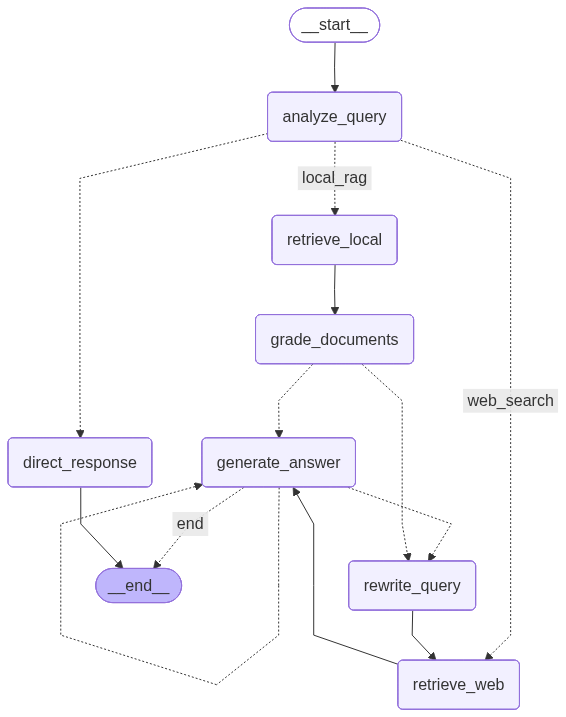

In [9]:

# ==============================================================================
# Step 7: Assemble the Graph
# ==============================================================================

workflow = StateGraph(AdaptiveRAGState)

# Add Nodes
workflow.add_node("analyze_query", analyze_query)
workflow.add_node("direct_response", direct_response)
workflow.add_node("retrieve_local", retrieve_local)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("rewrite_query", rewrite_query)
workflow.add_node("retrieve_web", retrieve_web)
workflow.add_node("generate_answer", generate_answer)

# Wire Edges
workflow.add_edge(START, "analyze_query")

workflow.add_conditional_edges(
    "analyze_query",
    route_initial_decision,
    {
        "direct_response": "direct_response",
        "local_rag": "retrieve_local",
        "web_search": "retrieve_web"
    }
)

workflow.add_edge("retrieve_local", "grade_documents")

workflow.add_conditional_edges(
    "grade_documents",
    route_document_grade,
    {
        "rewrite_query": "rewrite_query",
        "generate_answer": "generate_answer"
    }
)

workflow.add_edge("rewrite_query", "retrieve_web")
workflow.add_edge("retrieve_web", "generate_answer")

workflow.add_conditional_edges(
    "generate_answer",
    grade_generation_and_conclude,
    {
        "generate_answer": "generate_answer",
        "rewrite_query": "rewrite_query",
        "end": END
    }
)

workflow.add_edge("direct_response", END)

# Compile
compiled_graph = workflow.compile()
compiled_graph



In [12]:

# ==============================================================================
# Step 8: Execution and Demonstration
# ==============================================================================

if __name__ == "__main__":
    print("\n" + "=" * 80)
    print("ADAPTIVE RAG (SUPPORT CO-PILOT) - Starting Execution Demo")
    print("=" * 80)
    
    # Test Queries representing different paths:
    # 1. Direct Response (Greetings / Chit-chat)
    # 2. Local RAG (Specific VM query - found in local docs)
    # 3. Escalated/Web RAG (Troubleshooting outage - not in local docs, routes to web status)
    
    test_queries = [
        "hello how are you i am asim shah",
        "Hello! I hope you are having a nice day. Who do I email if I have a question about my bill?",
        "What SSD capacity and memory is provided under VM Tier-2?",
        "My instance is experiencing heavy packet loss in us-east-1 right now. Is there a status alert?"
    ]
    
    for idx, query in enumerate(test_queries, 1):
        print(f"\n\n[TEST CASE #{idx}] Query: \"{query}\"")
        print("-" * 80)
        
        inputs = {
            "messages": [HumanMessage(content=query)],
            "route": "direct_response",
            "retrieved_docs": [],
            "failed_attempts": 0,
            "rewritten_query": "",
            "generation": ""
        }
        
        result = compiled_graph.invoke(inputs, {"recursion_limit": 25})
        
        print("\n[RESULT]")
        print(f"Final Output:\n{result['generation']}")
        print("=" * 80)



ADAPTIVE RAG (SUPPORT CO-PILOT) - Starting Execution Demo


[TEST CASE #1] Query: "hello how are you i am asim shah"
--------------------------------------------------------------------------------

[1. Router] Analyzing query: 'hello how are you i am asim shah'
   Route Decided: DIRECT_RESPONSE (Reason: The user is engaging in greetings and introductions, which is suitable for a direct response.)

[Node: Direct Response] Processing direct reply...

[RESULT]
Final Output:
Hello Asim Shah, I'm doing well, thank you for asking. It's nice to meet you. Is there something I can help you with regarding CloudFlow, or would you like to know more about our support services? I'm here to assist you.


[TEST CASE #2] Query: "Hello! I hope you are having a nice day. Who do I email if I have a question about my bill?"
--------------------------------------------------------------------------------

[1. Router] Analyzing query: 'Hello! I hope you are having a nice day. Who do I email if I have a que

GraphRecursionError: Recursion limit of 25 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/GRAPH_RECURSION_LIMIT

# use iteration limit in circular loops as there are many loops so that infinite loops can be avoided